# DL Competition 01 — Image Classification (PyTorch)
**Intel Scene Classification — 6 Classes**

**Approach: Deep MLP with BatchNorm and Dropout**

### Architecture highlights:
1. **Grayscale images** (1 channel) — follows competition baseline preprocessing
2. **Deep MLP** with 4 hidden layers (1024 → 512 → 256 → 128)
3. **BatchNorm + Dropout** for strong regularization after every layer
4. **ReLU activations** — standard and reliable for classification tasks
5. **Adam optimizer** with StepLR scheduler for adaptive learning rate decay
6. **Early stopping** on validation accuracy to prevent overfitting
7. **Label smoothing** for better generalization on the 6-class problem

## Step 0: Kaggle Credentials (Colab only)

In [1]:
import os, json

# Write Kaggle credentials so the API can authenticate
os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_credentials = {
    "username": "jespanap",
    "key": "997974d829743c03f9607c887a7ace73"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle credentials configured.")

Kaggle credentials configured.


## Step 1: Download Dataset

In [2]:
# Download and extract only if not already present
if not os.path.exists('/content/intel-image-classification'):
    !pip install kaggle -q
    !kaggle datasets download -d puneet6060/intel-image-classification -p /content/
    !unzip -q /content/intel-image-classification.zip -d /content/intel-image-classification
    print("Dataset downloaded and extracted.")
else:
    print("Dataset already exists, skipping download.")

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 86% 298M/346M [00:00<00:00, 853MB/s] 
100% 346M/346M [00:00<00:00, 736MB/s]
Dataset downloaded and extracted.


## Step 2: Imports and Setup

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset, Dataset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import pandas as pd
import copy, time

# Device setup — use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if device == 'cuda':
    torch.cuda.manual_seed_all(42)

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print(f"Using device: {device}")

CUDA available: True
CUDA version: 12.8
Using device: cuda


## Step 3: Data Loading and Preprocessing

### Preprocessing Strategy
- **Grayscale (1 channel)** — follows the competition baseline; reduces input dimensionality
- **Resize to 150×150** — standard size for this competition
- **Normalize** with mean=0.5, std=0.5 — maps pixel values to approximately [-1, 1]
- Same transform applied to all splits (train, val, test, comp_test) for consistency

In [4]:
# Define the transformations — identical to the competition baseline
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to grayscale — 1 channel
    transforms.Resize((150, 150)),                # Resize to fixed 150×150 resolution
    transforms.ToTensor(),                        # Convert to tensor, values in [0, 1]
    transforms.Normalize(mean=[0.5], std=[0.5])   # Standardize to approximately [-1, 1]
])

### Load Training Dataset

In [5]:
train_path = '/content/intel-image-classification/seg_train/seg_train'

# ImageFolder assigns labels from subfolder names automatically
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Classes: {train_dataset.class_to_idx}")
print(f"Number of classes: {len(train_dataset.classes)}")

# Verify batch dimensions
for images, labels in train_loader:
    print(images.shape, labels.shape)
    break

Training samples: 14034
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Number of classes: 6
torch.Size([32, 1, 150, 150]) torch.Size([32])


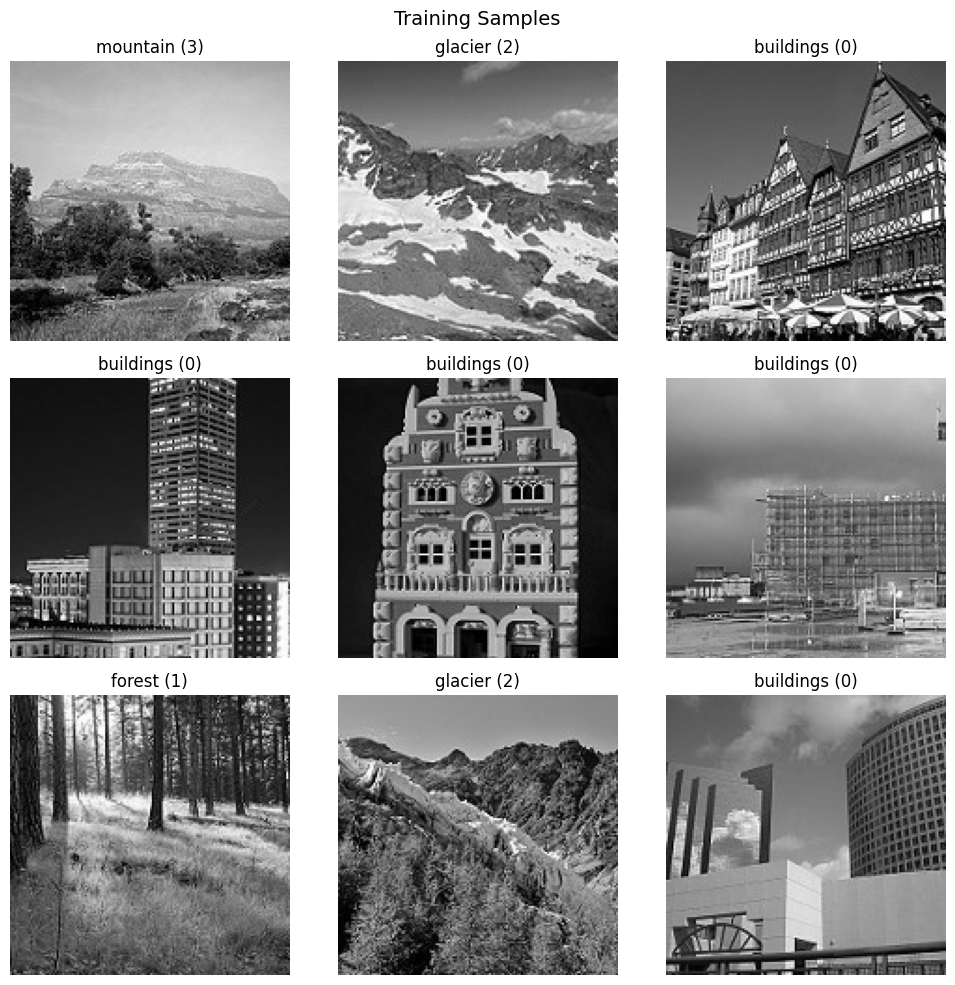

In [12]:
# Visualize sample training images — denormalize before plotting
CLASS_NAMES = train_dataset.classes

for images, labels in train_loader:
    images_vis = images * 0.5 + 0.5  # Reverse normalization for display

    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images_vis[i][0], cmap='gray')  # [0] extracts the single grayscale channel
        plt.title(f"{CLASS_NAMES[labels[i].item()]} ({labels[i].item()})")
        plt.axis('off')
    plt.suptitle("Training Samples", fontsize=14)
    plt.tight_layout()
    plt.show()
    break

### Load Validation and Test Datasets

Stratified split of seg_test into two samples of 100 images each, preserving class distribution.

Full seg_test samples: 3000
Validation samples: 100
Test samples: 100


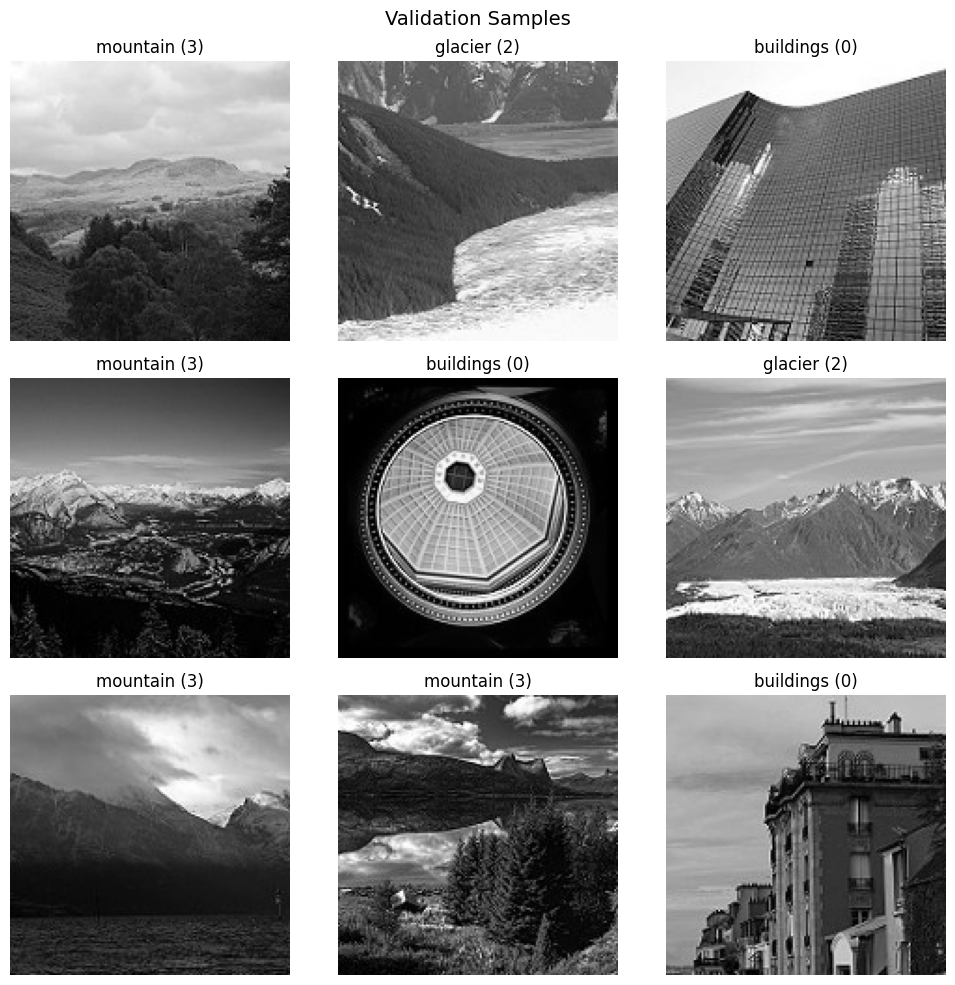

In [14]:
val_path = '/content/intel-image-classification/seg_test/seg_test'
val_dataset_full = datasets.ImageFolder(root=val_path, transform=transform)

targets = np.array(val_dataset_full.targets)  # Labels needed for stratification
sample_size    = 100  # Images per sample
num_iterations = 2    # Two samples: one for val, one for test

# StratifiedShuffleSplit ensures class balance in both subsets
splitter = StratifiedShuffleSplit(n_splits=num_iterations, test_size=sample_size, random_state=42)

sample_datasets = []
for _, sample_idx in splitter.split(np.zeros(len(targets)), targets):
    sample_datasets.append(Subset(val_dataset_full, sample_idx))

val_dataset  = sample_datasets[0]  # First sample → validation
test_dataset = sample_datasets[1]  # Second sample → internal test

val_loader  = DataLoader(val_dataset,  batch_size=100, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

print(f"Full seg_test samples: {len(val_dataset_full)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Visualize validation samples
for images, labels in val_loader:
    images_vis = images * 0.5 + 0.5
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images_vis[i][0], cmap='gray')
        plt.title(f"{CLASS_NAMES[labels[i].item()]} ({labels[i].item()})")
        plt.axis('off')
    plt.suptitle("Validation Samples", fontsize=14)
    plt.tight_layout()
    plt.show()
    break

### Load Competition Test Dataset (Unlabeled)

Competition test images selected: 200


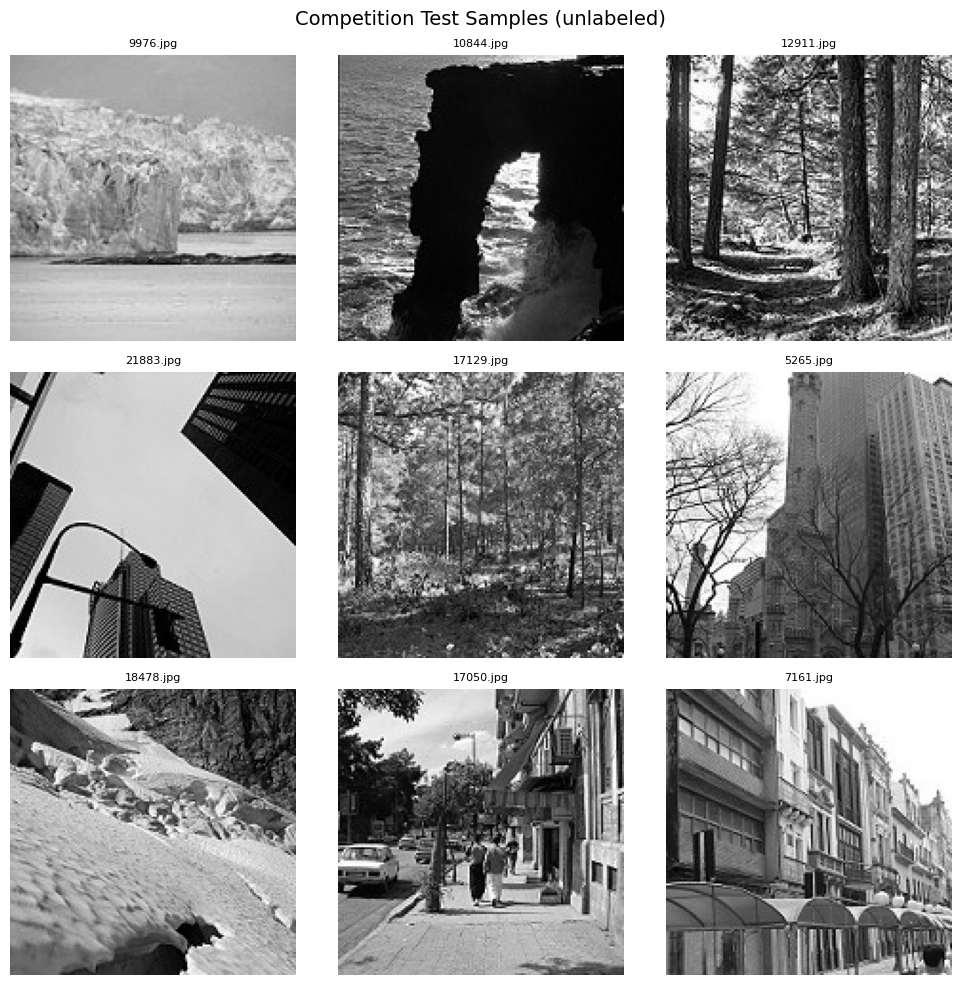

In [15]:
# comp_test has no class subfolders — requires a custom Dataset
image_directory = '/content/intel-image-classification/seg_pred/seg_pred'
image_files = os.listdir(image_directory)

# Filter to image extensions only
image_files = [f for f in image_files if f.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

# Select the first 200 images for inference
image_files = image_files[:200]


class SelectedFilesDataset(Dataset):
    def __init__(self, root_dir, file_names, transform=None):
        """
        Args:
            root_dir (str): Directory where files are stored.
            file_names (list): List of selected filenames (not full paths).
            transform (callable, optional): Transformations to apply to images.
        """
        self.root_dir   = root_dir
        self.file_names = file_names
        self.transform  = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_path = os.path.join(self.root_dir, self.file_names[idx])
        image = Image.open(file_path).convert('RGB')  # Load as RGB before transform

        if self.transform:
            image = self.transform(image)

        return image, self.file_names[idx]  # Return image tensor + filename


comp_test_dataset = SelectedFilesDataset(image_directory, image_files, transform=transform)
comp_test_loader  = DataLoader(comp_test_dataset, batch_size=100, shuffle=False)

print(f"Competition test images selected: {len(image_files)}")

# Visualize competition test samples (no labels available)
for images, names in comp_test_loader:
    images_vis = images * 0.5 + 0.5
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images_vis[i][0], cmap='gray')
        plt.title(names[i], fontsize=8)
        plt.axis('off')
    plt.suptitle("Competition Test Samples (unlabeled)", fontsize=14)
    plt.tight_layout()
    plt.show()
    break

## Step 4: Model Definition — Deep MLP with BatchNorm and Dropout

### Architecture Design Philosophy
MLPs operate on flattened pixel vectors, so we compensate for the lack of spatial inductive bias with:
- **Progressive dimensionality reduction** — learns hierarchical representations (1024 → 512 → 256 → 128)
- **BatchNorm** after every linear layer — stabilizes training and accelerates convergence
- **Dropout** at each layer — prevents co-adaptation of neurons and reduces overfitting
- **ReLU activations** — simple, effective, and well-suited for deep networks

### Architecture:
```
Input: 1×150×150 = 22,500 (flattened grayscale)
  → Linear(22500 → 1024) + BN + ReLU + Dropout(0.4)
  → Linear(1024  → 512)  + BN + ReLU + Dropout(0.4)
  → Linear(512   → 256)  + BN + ReLU + Dropout(0.3)
  → Linear(256   → 128)  + BN + ReLU + Dropout(0.2)
  → Linear(128   → 6)    — output logits
```

In [17]:
n_features = 1 * 150 * 150  # Grayscale 150×150 flattened
n_classes  = 6


class DeepMLP(nn.Module):
    """
    Deep MLP with BatchNorm and Dropout for image classification.
    Input: flattened grayscale image (1 x 150 x 150 = 22,500)
    Output: 6-class logits
    """
    def __init__(self, input_dim=22500, n_classes=6):
        super().__init__()

        self.net = nn.Sequential(
            # Layer 1: large initial projection to capture complex patterns
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            # Layer 2: halve the dimensionality
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            # Layer 3: continue compression
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            # Layer 4: final feature representation
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),

            # Output layer — no activation, CrossEntropyLoss applies softmax internally
            nn.Linear(128, n_classes)
        )

        self._init_weights()

    def _init_weights(self):
        # Kaiming initialization — optimal for ReLU networks
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # Flatten: (batch, 1, 150, 150) → (batch, 22500)
        return self.net(x)


# Initialize model and move to device
net = DeepMLP(input_dim=n_features, n_classes=n_classes).to(device)
print(net)

# Count parameters
total_params     = sum(p.numel() for p in net.parameters())
trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=22500, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True)
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=128, out_features=6, bias=True)
  )
)

Total parameter

## Step 5: Training Configuration

- **Loss:** CrossEntropyLoss with label smoothing (0.1) — penalizes overconfident predictions
- **Optimizer:** Adam — adaptive learning rates per parameter, fast convergence
- **Scheduler:** StepLR — halves the learning rate every 10 epochs for fine-grained convergence
- **Gradient clipping:** max_norm=1.0 — prevents gradient explosion in deep networks
- **Early stopping:** patience of 8 epochs on validation accuracy

In [19]:
# Loss function with label smoothing — softens hard targets to improve generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Adam optimizer — adaptive per-parameter learning rates
optimizer = optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)

# StepLR scheduler — reduces LR by half every 10 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Training configuration
num_epochs          = 40
early_stop_patience = 8

print("Training configuration ready.")
print(f"  Epochs: {num_epochs}")
print(f"  Batch size: {batch_size}")
print(f"  Optimizer: Adam (lr=1e-3, wd=1e-4)")
print(f"  Scheduler: StepLR (step=10, gamma=0.5)")
print(f"  Label smoothing: 0.1")
print(f"  Early stopping patience: {early_stop_patience}")

Training configuration ready.
  Epochs: 40
  Batch size: 32
  Optimizer: Adam (lr=1e-3, wd=1e-4)
  Scheduler: StepLR (step=10, gamma=0.5)
  Label smoothing: 0.1
  Early stopping patience: 8


## Step 6: Training Loop with Validation and Early Stopping

In [20]:
train_losses     = []
val_losses       = []
train_accuracies = []
val_accuracies   = []
best_val_acc     = 0.0
best_model_state = None
epochs_no_improve = 0
start_time       = time.time()

for epoch in range(num_epochs):

    # ===== Training Phase =====
    net.train()  # Enables BatchNorm and Dropout
    running_loss  = 0.0
    correct_train = 0
    total_train   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = net(images)
        loss    = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()

        running_loss  += loss.item() * images.size(0)
        _, predicted   = torch.max(outputs, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # Step LR scheduler after each epoch
    scheduler.step()

    train_loss = running_loss / total_train
    train_acc  = correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ===== Validation Phase =====
    net.eval()  # Disables BatchNorm and Dropout
    val_loss    = 0.0
    correct_val = 0
    total_val   = 0

    with torch.no_grad():  # No gradient computation needed for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val   += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / total_val
    val_acc  = correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    # Save best model checkpoint
    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        best_model_state = copy.deepcopy(net.state_dict())
        torch.save(net.state_dict(), '/content/best_model.pth')
        epochs_no_improve = 0
        marker = ' B'
    else:
        epochs_no_improve += 1
        marker = ''

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}{marker}")

    # Early stopping — halt if no improvement for N consecutive epochs
    if epochs_no_improve >= early_stop_patience:
        print(f"\n Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience} epochs)")
        break

elapsed = time.time() - start_time
print(f"\n Best Validation Accuracy: {best_val_acc:.4f}")
print(f" Training time: {elapsed/60:.1f} minutes")

Epoch [ 1/40] Train Loss: 1.6454 | Train Acc: 0.3808 | Val Loss: 1.4261 | Val Acc: 0.4600 | LR: 0.001000 B
Epoch [ 2/40] Train Loss: 1.5113 | Train Acc: 0.4384 | Val Loss: 1.4185 | Val Acc: 0.4900 | LR: 0.001000 B
Epoch [ 3/40] Train Loss: 1.4838 | Train Acc: 0.4527 | Val Loss: 1.3742 | Val Acc: 0.5100 | LR: 0.001000 B
Epoch [ 4/40] Train Loss: 1.4620 | Train Acc: 0.4689 | Val Loss: 1.3872 | Val Acc: 0.4900 | LR: 0.001000
Epoch [ 5/40] Train Loss: 1.4498 | Train Acc: 0.4734 | Val Loss: 1.3613 | Val Acc: 0.5300 | LR: 0.001000 B
Epoch [ 6/40] Train Loss: 1.4414 | Train Acc: 0.4731 | Val Loss: 1.3185 | Val Acc: 0.5000 | LR: 0.001000
Epoch [ 7/40] Train Loss: 1.4266 | Train Acc: 0.4884 | Val Loss: 1.3719 | Val Acc: 0.4800 | LR: 0.001000
Epoch [ 8/40] Train Loss: 1.4161 | Train Acc: 0.4897 | Val Loss: 1.3761 | Val Acc: 0.5100 | LR: 0.001000
Epoch [ 9/40] Train Loss: 1.4051 | Train Acc: 0.4978 | Val Loss: 1.3337 | Val Acc: 0.5300 | LR: 0.001000
Epoch [10/40] Train Loss: 1.3882 | Train Acc: 0

### Training and Validation Curves

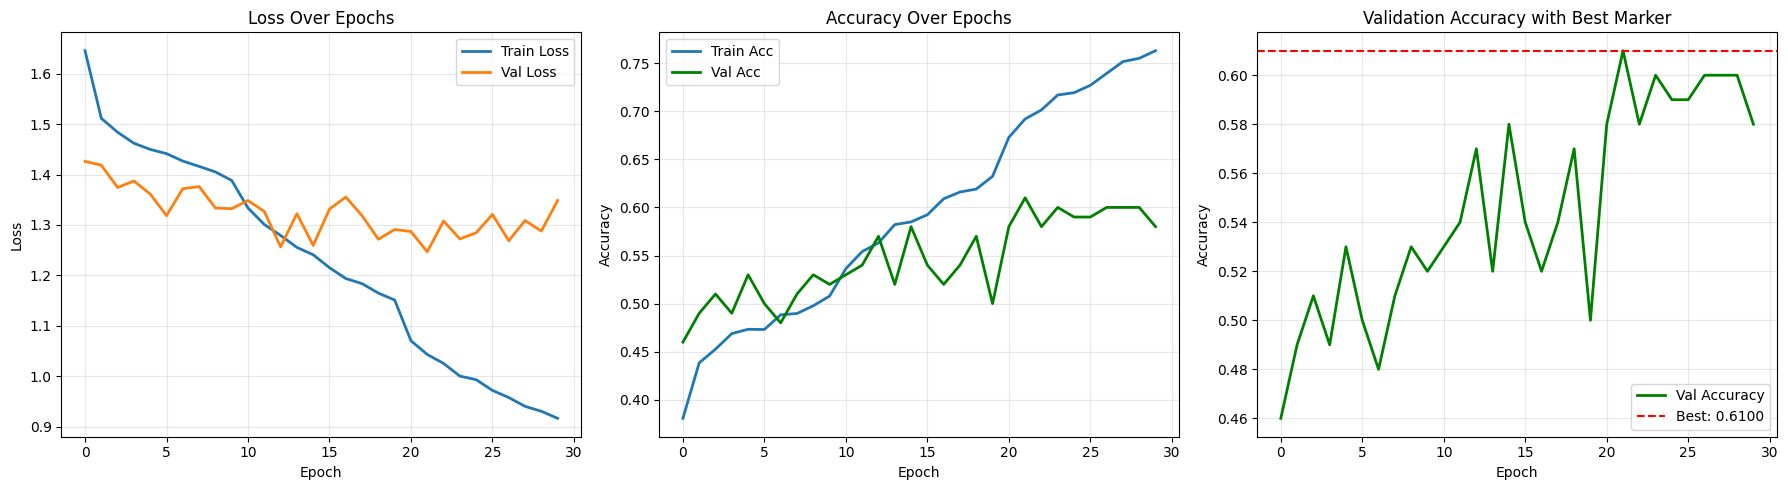

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses,   label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(train_accuracies, label='Train Acc', linewidth=2)
axes[1].plot(val_accuracies,   label='Val Acc',   linewidth=2, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Validation accuracy with best marker
axes[2].plot(val_accuracies, label='Val Accuracy', linewidth=2, color='green')
axes[2].axhline(y=best_val_acc, color='red', linestyle='--', label=f'Best: {best_val_acc:.4f}')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Validation Accuracy with Best Marker')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Test Set Evaluation (Sanity Check)

Load the best model and evaluate on the held-out internal test set.

In [24]:
# Load best model — evaluate without updating weights
net.load_state_dict(best_model_state)
net.eval()

correct_test = 0
total_test   = 0
all_preds    = []
all_labels   = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = net(images)
        _, predicted   = torch.max(outputs, 1)
        total_test    += labels.size(0)
        correct_test  += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = correct_test / total_test
print(f"Test Accuracy: {test_acc:.4f}")

# Per-class accuracy breakdown
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\nPer-class accuracy:")
for i, name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    if mask.sum() > 0:
        class_acc = (all_preds[mask] == all_labels[mask]).mean()
        print(f"  {name}: {class_acc:.4f} ({mask.sum()} samples)")

Test Accuracy: 0.5600

Per-class accuracy:
  buildings: 0.4000 (15 samples)
  forest: 0.7500 (16 samples)
  glacier: 0.6667 (18 samples)
  mountain: 0.4118 (17 samples)
  sea: 0.5294 (17 samples)
  street: 0.5882 (17 samples)


## Step 8: Generate Competition Predictions

In [26]:
# Ensure best model is loaded before inference
net.load_state_dict(best_model_state)
net.eval()

preds = []
ids   = []

with torch.no_grad():
    for images, names in comp_test_loader:
        # Forward pass
        Z = net(images.to(device))
        _, predicted = torch.max(Z, 1)
        preds.append(list(predicted.detach().cpu().numpy()))
        ids.append(list(names))

# Flatten list of batches
ids   = sum(ids,   [])
preds = sum(preds, [])

# Validate output length before saving
if len(ids) != len(preds):
    raise ValueError("The length of file_names and pred must be the same.")

# Create DataFrame and save CSV
df = pd.DataFrame({'id': ids, 'pred': preds})
csv_file = '/content/predictions.csv'
df.to_csv(csv_file, index=False)

print(f"CSV file '{csv_file}' created successfully.")
print(f"Total predictions: {len(df)}")
print(f"\nPrediction distribution:")
print(df['pred'].value_counts().sort_index())
print(f"\nFirst 10 rows:")
print(df.head(10))

CSV file '/content/predictions.csv' created successfully.
Total predictions: 200

Prediction distribution:
pred
0    21
1    40
2    28
3    38
4    32
5    41
Name: count, dtype: int64

First 10 rows:
          id  pred
0   9976.jpg     4
1  10844.jpg     5
2  12911.jpg     0
3  21883.jpg     5
4  17129.jpg     1
5   5265.jpg     0
6  18478.jpg     2
7  17050.jpg     5
8   7161.jpg     5
9  19254.jpg     4


## Step 9: Download predictions.csv

In [27]:
# Download the CSV directly to your local machine from Colab
from google.colab import files
files.download('/content/predictions.csv')
print("Download started — check your Downloads folder.")
print("Next step: upload predictions.csv to https://huggingface.co/spaces/MLEAFIT/DLComp0120261")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started — check your Downloads folder.
Next step: upload predictions.csv to https://huggingface.co/spaces/MLEAFIT/DLComp0120261


## Done!
The `predictions.csv` file is saved and ready for submission to HuggingFace.

### Model Summary — Deep MLP
| Aspect | Detail |
|--------|--------|
| Architecture | Deep MLP (4 hidden layers) |
| Input | Grayscale 1ch, 150×150, flattened to 22,500 |
| Activations | ReLU |
| Regularization | Dropout (0.2–0.4) + BatchNorm + Weight Decay (1e-4) + Label Smoothing (0.1) |
| Optimizer | Adam (lr=1e-3, wd=1e-4) |
| Scheduler | StepLR (step=10, gamma=0.5) |
| Gradient clipping | max_norm=1.0 |
| Early stopping | patience=8 on val accuracy |